<div style="display:flex;justify-content:space-between;border-bottom:1px solid #8A8A8A;padding-bottom:3px;font-size:0.95em;">
<span>Traitement d'images</span><span>2026-2027</span>
</div>

# TP n° 1 : Images numériques, couleur et robustesse

<div style="border:2px solid #6B7B7B;border-radius:6px;margin:0.8em 0;overflow:hidden;">
<div style="background:#414C4C;color:#fff;font-weight:bold;padding:4px 14px;">Objectif</div>
<div style="padding:4px 14px;">

À la fin du TP, vous devrez être capable de :

- relier la forme d'un tableau à la représentation d'une image ;
- effectuer des calculs sans débordement ni écrêtage involontaire ;
- extraire et afficher une région d'intérêt ;
- interpréter séparément les composantes RGB et HSV ;
- construire un détecteur de couleur et mesurer ses erreurs ;
- régler une méthode sur une image puis évaluer sa robustesse sur d'autres.

**Durée estimée** : 3 heures (*et des grosses poussières*)

</div></div>

Ce TP utilise *NumPy* et *Matplotlib*, vus l'année précédente. Les rappels nécessaires sont intégrés au sujet au moment où vous en avez besoin. Lisez-les même si les bibliothèques vous sont familières : ils fixent les conventions utilisées dans tout le TP.

## Progression attendue

- La partie obligatoire comprend les sections 1 à 5, 6.1, 6.2 et 7.2 ;
- La partie approfondissement comprend les sections 6.3, 7.1 et 8 à 11 ;
- Dès que la partie obligatoire est terminée, poursuivez avec l'approfondissement.

## Assistant IA

Vous pouvez utiliser un assistant IA pour comprendre un concept, proposer du code ou corriger une erreur. Vous restez responsable de chaque résultat produit : vous devez pouvoir expliquer le code retenu, vérifier ses résultats et justifier vos choix à partir de vos propres mesures.

Le code seul ne constitue donc pas une réponse. Conservez dans le bloc-notes les figures, les mesures et les réponses demandées.

## Avant de commencer

Ce bloc-notes doit être ouvert depuis Jupyter lancé dans l'environnement `.venv`, comme l'explique
`README-tp1.md`. Les deux cellules suivantes vérifient l'environnement et localisent le dossier
`ressources-tp1` : commencez le TP seulement si elles s'exécutent sans erreur.

In [ ]:
import importlib.util
import sys

manquantes = [m for m in ("numpy", "matplotlib", "skimage")
              if importlib.util.find_spec(m) is None]
if manquantes:
    raise ModuleNotFoundError(
        "Bibliothèques absentes : " + ", ".join(manquantes) + ". Fermez Jupyter, "
        "activez .venv dans le terminal (source .venv/bin/activate), puis relancez "
        "python -m jupyter notebook depuis le dossier traitement-images "
        "(sous Windows : .venv\\Scripts\\activate)."
    )
print("Environnement correct :", sys.executable)

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib import patches
import numpy as np
from skimage import color, io, transform, util

print("Interpréteur :", sys.executable)
print("NumPy :", np.__version__)


def locate_resources() -> Path:
    """Locate traitement-images/ressources-tp1 from common working directories."""
    candidates = (
        Path.cwd() / "ressources-tp1",
        Path.cwd().parent / "ressources-tp1",
        Path.cwd() / "traitement-images" / "ressources-tp1",
    )
    for candidate in candidates:
        if (candidate / "04-balles-reference.jpg").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Dossier ressources-tp1 introuvable : vérifiez son extraction dans "
        "la racine traitement-images"
    )


RESOURCES = locate_resources()
print("Ressources :", RESOURCES)

### Réflexes *NumPy* et *Matplotlib* à avoir dans ce TP

Une image est un tableau *NumPy*. Les opérations portent généralement sur tous les pixels à la fois : évitez les boucles imbriquées sur `x` et `y`.

```python
image.shape                 # dimensions du tableau
image.dtype                 # type de ses valeurs (uint8, uint16, float64, etc.)
image.min(), image.max()    # plage effectivement utilisée
image[y, x]                 # valeur à la ligne y et à la colonne x
image[y0:y1, x0:x1]         # région : y1 et x1 sont exclus
image[..., 0]               # première composante de tous les pixels
mask = image > threshold    # tableau booléen de même hauteur et largeur
image[mask]                 # valeurs pour lesquelles mask est vrai
```

Pour plusieurs images, `plt.subplots` renvoie la figure et un tableau d'axes. `axes.flat` permet de parcourir une grille quelle que soit sa forme.

```python
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, image, title in zip(axes, images, titles):
    axis.imshow(image, cmap="gray")
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
```

Exécutez chaque cellule dès qu'elle est complétée. Vérifiez les formes des tableaux, les plages de valeurs et les résultats avant de poursuivre : une cellule qui s'exécute sans erreur **ne garantit pas** que le résultat soit correct.

## 1. Rappels : figures, sous-figures et découpage

Une image en niveaux de gris est généralement représentée par un tableau de la forme `(hauteur, largeur)`. Une image RGB est représentée, quant à elle, par un tableau de la forme `(hauteur, largeur, 3)`.

Dans `image[y, x, c]`, `y` désigne la ligne, `x` la colonne et `c` le canal.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : pixel, canal et forme d'une image**

Une image numérique est un tableau de nombres ; un pixel est une position (y, x) de ce tableau. Une image en niveaux de gris a une valeur par pixel, de forme `(hauteur, largeur)`. Une image RGB en a trois, les canaux rouge, vert et bleu, de forme `(hauteur, largeur, 3)`. Le format RGBA ajoute un quatrième canal, l'opacité alpha.

**Exemple :** une image de forme `(100, 200, 3)` contient 100 $\times$ 200 = 20 000 pixels et 3 $\times$ 20 000 = 60 000 valeurs.

</div></div>

![Indexation image[y, x]](attachment:indexation.png)

*Figure 1 : le premier indice désigne la ligne y, le second la colonne x ; dans une tranche, la fin est exclue.*
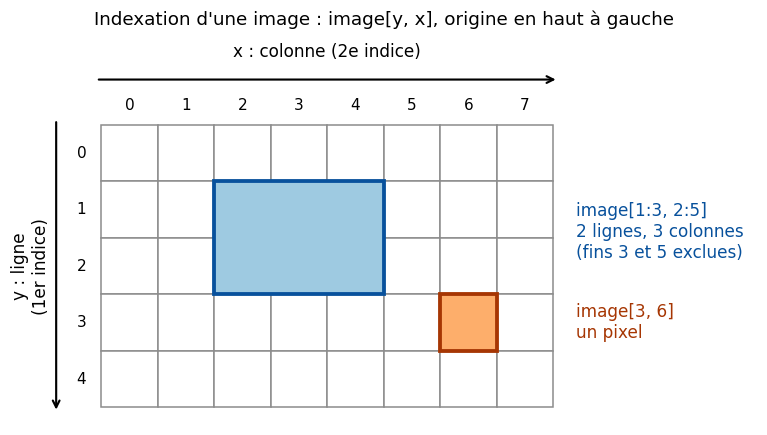

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">io.imread</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">plt.subplots</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.imshow</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.set_title</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.axis</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">zip</code>.

</div></div>

In [ ]:
gray = io.imread(RESOURCES / "02-ensicaen-niveaux-gris.jpg")
rgb = io.imread(RESOURCES / "04-balles-reference.jpg")
rgba = io.imread(RESOURCES / "03-billet-50-euros-rgba.png")
axes_image = io.imread(RESOURCES / "01-axes-canaux.png")

print("Niveaux de gris :", gray.shape, gray.dtype)
print("RGB :", rgb.shape, rgb.dtype)
print("RGBA :", rgba.shape, rgba.dtype)
print("Image synthétique :", axes_image.shape, axes_image.dtype)

### 1.1 Figures et sous-figures

Affichez les quatre images dans une grille de deux lignes et deux colonnes.
Procédez en quatre étapes :

1. Placez les images dans une liste ou un tuple.
2. Préparez quatre titres dans le même ordre.
3. Parcourez `axes.flat`, les images et les titres avec la fonction `zip`.
4. Dans la boucle, appelez `imshow`, `set_title` et `axis("off")`

Une image scalaire doit être affichée avec l'argument `cmap="gray"` (`gray` est la palette de "couleurs"). Pour les images en couleur, ne fournissez pas de palette. Utilisez `interpolation="nearest"` pour l'image synthétique afin de voir ses pixels sans lissage.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# TODO : afficher gray, rgb, rgba et axes_image
# Pour l'image synthétique, utilisez interpolation="nearest"

plt.tight_layout()

### 1.2 Indexation et découpage

Commencez par afficher `axes_image.shape`. Déduisez-en les indices de la dernière ligne et de la dernière colonne, puis :

1. Affichez les valeurs des quatre coins avec `[y, x]`. L'indice `-1` désigne la dernière ligne ou la dernière colonne.
2. Extrayez la moitié droite avec `axes_image[:, x0:]`.
3. Extrayez le rectangle blanc central avec `axes_image[y0:y1, x0:x1]`.
4. Affichez l'image complète et les deux extraits avec `interpolation="nearest"`

Vérifiez les dimensions de chaque extraction avec `.shape` avant de l'afficher.

In [ ]:
# TODO : afficher axes_image.shape, puis les valeurs des quatre coins

In [ ]:
# TODO : compléter les tranches
right_half = axes_image[:, ...]
white_center = axes_image[..., ...]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# TODO : afficher l'image complète et les deux régions extraites
plt.tight_layout()

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 1**

En une phrase, expliquez quelle zone est extraite si l'on inverse les indices et si l'on écrit `[x, y]` à la place de `[y, x]`.

</div>

**Réponse à la question 1**

*Écrivez votre réponse ici.*

### 1.3 Décrire correctement une image

Complétez la fonction `describe_image` ci-dessous. Commencez par récupérer la hauteur et la largeur avec `image.shape[:2]`. Une image de dimension 2 possède un canal ; pour une image de dimension 3, le nombre de canaux est `image.shape[2]`.

Le dictionnaire retourné doit contenir :

- la hauteur et la largeur ;
- le nombre de canaux ;
- le type des composantes ;
- les valeurs minimale et maximale ;
- le nombre de pixels ;
- le nombre total de valeurs scalaires ;
- l'occupation mémoire en octets.

Les attributs utiles sont `ndim`, `shape`, `dtype`, `size` et `nbytes`. Le nombre de pixels vaut `hauteur * largeur`, indépendamment du nombre de canaux.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Attributs utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.ndim</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.shape</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.dtype</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.size</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.nbytes</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.min()</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.max()</code>.

</div></div>

In [ ]:
def describe_image(image: np.ndarray) -> dict:
    """Return the structural and numerical properties of an image."""
    # TODO
    raise NotImplementedError


for name, image in {"gris": gray, "RGB": rgb, "RGBA": rgba}.items():
    print(name, describe_image(image))

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 2**

Donnez la valeur renvoyée par `image.size` et le nombre de pixels pour l'image RGB, puis expliquez
le facteur qui relie les deux valeurs.

</div>

**Réponse à la question 2**

*Écrivez votre réponse ici.*

<div style="border:2px solid #6B7B7B;border-radius:6px;margin:0.8em 0;overflow:hidden;">
<div style="background:#414C4C;color:#fff;font-weight:bold;padding:4px 14px;">Point de contrôle n°1</div>
<div style="padding:4px 14px;">

Montrez au moins une figure et les trois dictionnaires à votre encadrant.
Si vous connaissez déjà bien *NumPy* et *Matplotlib*, poursuivez immédiatement.

</div></div>

## 2. Calculer sans dégrader les données

Le type `uint8` représente les entiers de 0 à 255. Il ne peut pas représenter
260 ni 265. Sans exécuter la cellule suivante, devinez d'abord les quatre
résultats que vous attendez, puis comparez-les à ceux produits par *NumPy*.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : débordement (`uint8`)**

Le type `uint8` ne stocke que les entiers de 0 à 255. Si un calcul dépasse 255, le résultat repart de 0 : il est calculé modulo 256.

**Exemple :** 250 + 10 = 260 n'existe pas en `uint8` ; on obtient 260 - 256 = 4.

</div></div>

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.array</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">dtype=np.uint8</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.astype</code>.

</div></div>

In [ ]:
values = np.array([0, 10, 250, 255], dtype=np.uint8)
print("Avant :", values)
print("Après ajout de 10 :", values + 10)

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 3**
 
Recopiez les deux valeurs inattendues obtenues pour 250 et 255. Expliquez le retour au début de la
plage `uint8`, puis proposez une ligne de code qui convertit vers un type plus large avant l'addition.

</div>

**Réponse à la question 3**

*Écrivez votre réponse ici.*

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : écrêtage**

Quand une valeur calculée sort de la plage autorisée, par exemple [0, 1], l'écrêtage la ramène à la borne la plus proche. Une valeur négative devient 0, une valeur supérieure à 1 devient 1, et les autres ne changent pas. En Python : `np.clip(x, 0, 1)`.

**Exemple :** avec a = 2 et m = 0,5, un pixel à 0,90 donne 0,5 + 2 $\times$ 0,40 = 1,30, et un pixel à 0,95 donne 1,40. Les deux sont écrêtés à 1 : deux pixels différents deviennent identiques, et l'information est perdue.

**À ne pas confondre :** le débordement repart de 0 (250 + 10 donne 4), alors que l'écrêtage bloque à la borne (1,30 donne 1).

</div></div>

Convertissez l'image `gray` en flottants avec `util.img_as_float`, puis implémentez la transformation
affine centrée suivante :

$$\boxed{\displaystyle I_{\text{sortie}} = \operatorname{clip}(m + a(I_{\text{entrée}}-m) + b, 0, 1)}$$

avec $m=0,5$. Procédez dans cet ordre :

1. Calculez le résultat non écrêté dans une variable `raw`.
2. Calculez `np.mean(raw < 0)` et `np.mean(raw > 1)` ; sur un masque booléen, la moyenne est la
   proportion de valeurs vraies.
3. Appliquez `np.clip(raw, 0, 1)`.
4. Retournez l'image et les deux proportions.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">util.img_as_float</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.mean</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.clip</code>.

</div></div>

In [ ]:
def affine_intensity(
    image: np.ndarray, a: float, b: float, midpoint: float = 0.5
) -> tuple[np.ndarray, float, float]:
    """Apply a centered affine intensity transform and report clipping rates."""
    # TODO
    raise NotImplementedError


gray_float = util.img_as_float(gray)

# Testez exactement les couples suivants : `(1, 0)`, `(1.8, 0)`, `(1, 0.18)`
# et `(0.6, 0)`. Affichez les quatre résultats sur une ligne. Dans chaque titre,
# indiquez `a`, `b` et les deux pourcentages d'écrêtage (multipliez les
# proportions par 100).

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 4**

À partir des quatre images et des pourcentages :

1. Indiquez l'effet de `a` sur l'écart entre les zones claires et sombres.
2. Indiquez l'effet de `b` sur le niveau moyen.
3. Donnez le couple qui écrête le plus de pixels et précisez de quel côté.

</div>

**Réponse à la question 4**

*Écrivez votre réponse ici.*

## 3. Région d'intérêt et changement d'échelle

Convertissez le billet de banque factice de RGBA en RGB, puis en niveaux de gris. Affichez d'abord
le billet seul et relevez approximativement les limites du bloc "50 EURO" en bas à gauche, y compris la ligne de microtexte en dessous. Définissez ensuite
`x0`, `x1`, `y0` et `y1`, puis extrayez la région avec `euro_gray[y0:y1, x0:x1]`.

Affichez côte à côte :

- l'image complète avec un rectangle rouge autour de ce bloc ;
- la région extraite.

Rappel : une tranche (*slice*) s'écrit `image[y0:y1, x0:x1]`, tandis que le rectangle généré par 
*Matplotlib* reçoit le point `(x0, y0)`, puis une largeur et une hauteur.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : région d'intérêt et tranche**

Une région d'intérêt est la partie de l'image utile à une analyse. On l'extrait par une tranche `image[y0:y1, x0:x1]`, qui garde les lignes y0 à y1 - 1 et les colonnes x0 à x1 - 1 : les fins sont exclues.

**Exemple :** `image[10:20, 30:50]` contient 20 - 10 = 10 lignes et 50 - 30 = 20 colonnes.

</div></div>

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">color.rgba2rgb</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">color.rgb2gray</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">patches.Rectangle</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.add_patch</code>.

</div></div>

In [ ]:
euro_rgb = color.rgba2rgb(rgba)
euro_gray = color.rgb2gray(euro_rgb)

# TODO : déterminer les quatre coordonnées
x0, x1 = ..., ...
y0, y1 = ..., ...
euro_roi = euro_gray[y0:y1, x0:x1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(euro_gray, cmap="gray")
axes[0].add_patch(
    patches.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        linewidth=2, edgecolor="red", facecolor="none"
    )
)
axes[1].imshow(euro_roi, cmap="gray")
for axis in axes:
    axis.axis("off")
plt.tight_layout()

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : interpolation**

Agrandir une image oblige à calculer des valeurs entre les pixels connus. Le plus proche voisin recopie la valeur du pixel le plus proche. L'interpolation bilinéaire fait une moyenne des voisins, pondérée par la distance. La bicubique utilise plus de voisins et une courbe plus lisse.

**Exemple :** entre deux pixels voisins qui valent 0,2 et 0,8, un nouveau pixel placé exactement au milieu vaut 0,5 en bilinéaire. En plus proche voisin, il recopie l'un des deux, 0,2 ou 0,8.

</div></div>

Réduisez la région d'un facteur 10 dans chaque direction. La nouvelle forme
est `(hauteur // 10, largeur // 10)`. Utilisez `transform.resize` avec
`order=1` et `anti_aliasing=True` pour cette réduction. L'anti-repliement
applique un lissage avant le sous-échantillonnage afin de limiter les motifs
artificiels produits lorsque des variations trop fines ne peuvent plus être
représentées sur la nouvelle grille.

Ramenez ensuite l'image réduite à `euro_roi.shape` avec :

- plus proche voisin (`order=0`)
- bilinéaire (`order=1`)
- bicubique (`order=3`), qui combine davantage de voisins par une interpolation
  cubique et peut produire un résultat plus lisse

Placez les trois images agrandies dans un dictionnaire `restored`. Pour chaque
méthode, affichez le résultat et calculez l'erreur absolue moyenne par rapport
à la région initiale : `mean(abs(reference - estimate))`. Convertissez les
tableaux en flottants avant la soustraction. Cette mesure compare les valeurs
pixel par pixel ; elle ne constitue pas, à elle seule, une mesure de qualité
visuelle.

**Prédiction** 

Avant de calculer, indiquez quelle interpolation donnera selon vous la plus petite erreur, et pourquoi.

**Votre prédiction**

*Écrivez votre prédiction ici, avant d'exécuter la cellule de code suivante.*

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">transform.resize</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.astype(float)</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.abs</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.mean</code>.

</div></div>

In [ ]:
def mean_absolute_error(reference: np.ndarray, estimate: np.ndarray) -> float:
    # TODO
    raise NotImplementedError


# TODO : réduire, agrandir, afficher et mesurer

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 5**

Donnez l'erreur des trois interpolations, identifiez la plus faible, puis expliquez pourquoi retrouver
le nombre initial de lignes et de colonnes ne recrée pas les détails supprimés lors de la réduction.
Votre prédiction était-elle juste ? Sinon, quelle hypothèse était fausse ?

</div>

**Réponse à la question 5**

*Écrivez votre réponse ici.*

## 4. Composantes RGB et HSV

Convertissez l'image des balles (`04-balles-reference.jpg`, variable `balls`) en flottants puis en HSV. Créez une
grille `2 x 4`. Placez l'image RGB en haut à gauche, R, G et B dans les trois autres cases de la
première ligne, puis H, S et V sur la seconde ligne. Laissez la dernière case vide.

Une composante s'extrait avec `balls[..., index]` ou `hsv[..., index]`. Utilisez `vmin=0`, `vmax=1`,
une palette `gray` pour R, G, B, S et V, et la palette `hsv` pour H. L'objet retourné par `imshow`
peut être transmis à `fig.colorbar(..., ax=axis)`.

N'affichez pas directement le tableau HSV comme une image RGB : *Matplotlib* interpréterait ses
trois valeurs comme des intensités rouge, verte et bleue.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : espace HSV**

HSV décrit une couleur par trois nombres entre 0 et 1. La teinte H indique la couleur sur un cercle : rouge vers 0, jaune vers 0,17, vert vers 0,33, bleu vers 0,67. La saturation S mesure la pureté de la couleur, avec 0 pour un gris et 1 pour une couleur vive. La valeur V vaut le maximum de R, G et B.

**Exemple :** le jaune pur (R, G, B) = (1, 1, 0) donne H $\approx$ 0,17, S = 1 et V = 1. Un gris (0,5 ; 0,5 ; 0,5) donne S = 0 et V = 0,5, et sa teinte n'a pas de sens.

</div></div>

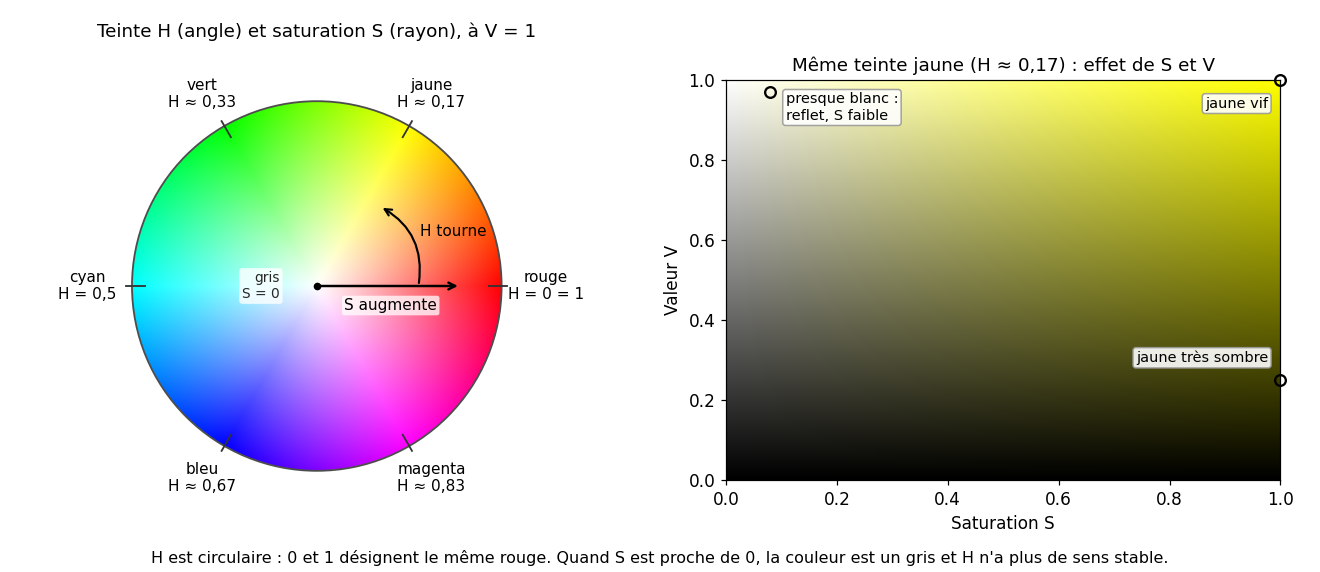

*Figure 2 : la teinte H est un angle, la saturation S un rayon et la valeur V une luminosité.*

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">color.rgb2hsv</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.imshow(..., vmin=0, vmax=1)</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">fig.colorbar</code>.

</div></div>

In [ ]:
balls = util.img_as_float(rgb)
hsv = color.rgb2hsv(balls)

# TODO : créer une figure contenant l'image et les six composantes

Relevez H, S et V pour les quatre positions `(x, y)` suivantes :

- jaune : `(995, 500)`
- rouge : `(1400, 500)`
- bleu : `(1200, 950)`
- reflet clair sur la balle jaune : `(1013, 480)`

Pour chaque entrée du dictionnaire, décomposez `(x, y)`, puis lisez
`hsv[y, x, :]`. Affichez les trois valeurs avec trois chiffres après la
virgule. Cette mesure doit vous aider à choisir les seuils de la section 5.

In [ ]:
sample_points = {
    "jaune": (995, 500),
    "rouge": (1400, 500),
    "bleu": (1200, 950),
    "reflet": (1013, 480),
}

# TODO : relever les valeurs HSV en respectant l'ordre [y, x]

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 6**

Comparez les valeurs H des points jaune, rouge et bleu. Puis comparez la saturation du jaune et
celle du reflet. Expliquez pourquoi une petite variation RGB rend H instable lorsque S est proche
de zéro.

</div>

**Réponse à la question 6**

*Écrivez votre réponse ici.*

## 5. Étude de cas commune : détecter des balles jaunes à partir de leur teinte

La cible de cette étude est l'ensemble des pixels appartenant aux balles que
l'annotation désigne comme jaunes. Ce n'est pas l'ensemble absolu de toutes les
couleurs qui pourraient être qualifiées de jaunes dans l'image.

Construisez un premier détecteur qui conserve un pixel si sa teinte est proche
du jaune, sa saturation suffisante et sa valeur suffisante.

La teinte est circulaire : 0 et 1 représentent la même teinte. La distance
directe `abs(hue - center)` ne suffit donc pas près de cette frontière. Pour
chaque pixel, calculez d'abord cette distance directe, puis prenez le minimum
entre `direct` et `1 - direct`.

Dans `segment_yellow_hsv`, suivez ces étapes :

1. Convertissez `image_rgb` en HSV.
2. Calculez la distance circulaire entre H et `hue_center`.
3. Construisez trois masques booléens pour H, S et V.
4. Combinez-les avec l'opérateur `&` ; placez chaque comparaison entre parenthèses.

Avant d'utiliser le réglage fourni, proposez vos propres seuils à partir de
vos mesures de la section 4 : une teinte centrale, une tolérance, une
saturation minimale et une valeur minimale. Écrivez-les dans
`my_hsv_parameters`. Vous calculerez leurs métriques dans `my_hsv_scores` plus
tard, une fois `binary_metrics` écrite (sous-section « Comparer deux masques
binaires »). Pour
que les résultats restent comparables d'un étudiant à l'autre, la suite du TP
utilise le réglage fourni par `hsv_parameters`.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : distance circulaire de teinte**

La teinte est un angle : H = 0 et H = 1 désignent le même rouge. La distance entre deux teintes est le plus court chemin sur le cercle : $d=\min\left(|H_1-H_2|\,;\,1-|H_1-H_2|\right)$.

**Exemple :** entre 0,95 et 0,05, la distance directe vaut 0,90, mais la distance circulaire vaut min(0,90 ; 0,10) = 0,10. Les deux teintes sont presque identiques.

</div></div>

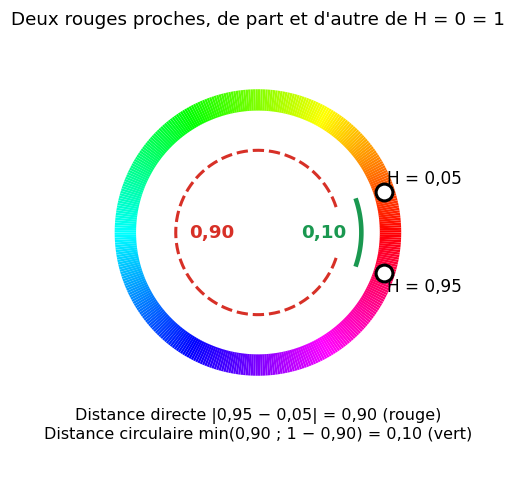

*Figure 3 : deux teintes rouges proches sont séparées par 0,10 sur le cercle, pas par 0,90.*

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.abs</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.minimum</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">color.rgb2hsv</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">&</code>.

</div></div>

In [ ]:
def circular_hue_distance(hue: np.ndarray, center: float) -> np.ndarray:
    """Return the shortest distance between hues encoded in [0, 1]."""
    # TODO
    raise NotImplementedError


def segment_yellow_hsv(
    image_rgb: np.ndarray,
    hue_center: float,
    hue_tolerance: float,
    saturation_min: float,
    value_min: float,
) -> np.ndarray:
    """Return a boolean mask selecting yellow pixels."""
    # TODO
    raise NotImplementedError


# Commencez avec les paramètres ci-dessous. Ils constituent le réglage initial
# qui devra rester fixe pendant les validations suivantes.
hsv_parameters = (0.14, 0.05, 0.35, 0.25)
# ordre : hue_center, hue_tolerance, saturation_min, value_min

# TODO : vos propres seuils, justifiés par vos mesures de la section 4
my_hsv_parameters = (..., ..., ..., ...)

# TODO : calculer `hsv_mask` avec `segment_yellow_hsv`

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : masque binaire**

Un masque binaire est un tableau de booléens de même hauteur et de même largeur que l'image. Il vaut `True` là où un pixel est sélectionné et `False` ailleurs. On le combine avec `&` (et), `|` (ou) et `~` (non).

**Exemple :** pour les valeurs [0,2 ; 0,7 ; 0,9], `image > 0.5` donne [False, True, True], et `~(image > 0.5)` donne [True, False, False].

</div></div>

Affichez l'image, le masque, la superposition colorée et les pixels conservés
sur fond noir.

Pour construire la superposition, copiez d'abord l'image flottante. Pour les
seuls pixels sélectionnés par `mask`, remplacez la couleur par le mélange :

$$\boxed{\displaystyle I_{\text{sortie}}=(1-\alpha)I+\alpha C}$$

où $C$ est la couleur de superposition. Un masque booléen permet d'écrire
directement `output[mask] = ...`.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.asarray</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.copy()</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.zeros_like</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">output[mask] = ...</code>.

</div></div>

In [ ]:
def overlay_mask(
    image: np.ndarray, mask: np.ndarray, color_rgb=(1.0, 0.0, 1.0), alpha=0.45
) -> np.ndarray:
    """Overlay a solid color on selected pixels."""
    # TODO
    raise NotImplementedError


# Pour les pixels conservés sur fond noir, créez `np.zeros_like(balls)`, puis
# copiez uniquement les valeurs pour lesquelles `hsv_mask` est vrai. Produisez
# ensuite une figure 1 x 4 avec un titre par résultat.

### Mesurer les erreurs

Le fichier `05-balles-annotation-reference.png` contient l'annotation de
référence des balles jaunes. Leur contour a été tracé à la main, puis ajusté
par un cercle sur les bords des balles détectés dans l'image, sans aucune règle
de couleur. Les
reflets appartiennent aux balles. La balle orangée en bas à gauche et la balle
pâle et floue à l'arrière-plan ne sont pas annotées : ce choix de définition
fait partie de la référence. Le long du contour des balles, l'annotation est
précise à deux pixels environ.

### Comparer deux masques binaires

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : VP, FP, FN, précision, rappel et IoU**

Notons $G$ l'ensemble des pixels vrais dans le masque de référence et $P$
l'ensemble des pixels vrais dans le masque prédit :

- $P\cap G$ contient les pixels sélectionnés dans les deux masques
- $P\cup G$ contient les pixels sélectionnés dans au moins un des deux masques

L'**intersection sur union**, ou **IoU** (*intersection over union*, également
appelée indice de Jaccard), mesure leur recouvrement :

$$\boxed{\displaystyle \mathrm{IoU}(P,G)=\frac{|P\cap G|}{|P\cup G|}}$$

$|\cdot|$ désigne ici un nombre de pixels. L'IoU vaut 1 lorsque les deux
masques sont identiques et non vides, et 0 lorsqu'ils ne partagent aucun pixel
vrai. Les vrais négatifs n'interviennent pas : le grand nombre de pixels du
fond ne peut donc pas masquer une mauvaise segmentation de l'objet.

La même définition peut s'écrire en comptant trois catégories de pixels :

- **vrai positif** (VP) : pixel d'une balle annotée, correctement sélectionné ;
- **faux positif** (FP) : pixel hors des balles annotées, sélectionné à tort ;
- **faux négatif** (FN) : pixel d'une balle annotée, oublié.

$$\boxed{\displaystyle \text{précision} = \frac{VP}{VP+FP}}$$

$$\boxed{\displaystyle \text{rappel} = \frac{VP}{VP+FN}}$$

$$\boxed{\displaystyle \mathrm{IoU} = \frac{VP}{VP+FP+FN}}$$

Dans ce TP, si les deux masques sont vides, nous fixerons l'IoU à 1 car ils
sont en accord. Une précision sans pixel prédit ou un rappel sans pixel de
référence sont mathématiquement indéfinis : la fonction retournera `np.nan`.

**Exemple :** pour les deux masques 3 $\times$ 3 de la cellule suivante, VP = 3, FP = 1 et FN = 1, donc précision = rappel = 3 / 4 = 0,75 et IoU = 3 / 5 = 0,60.

</div></div>

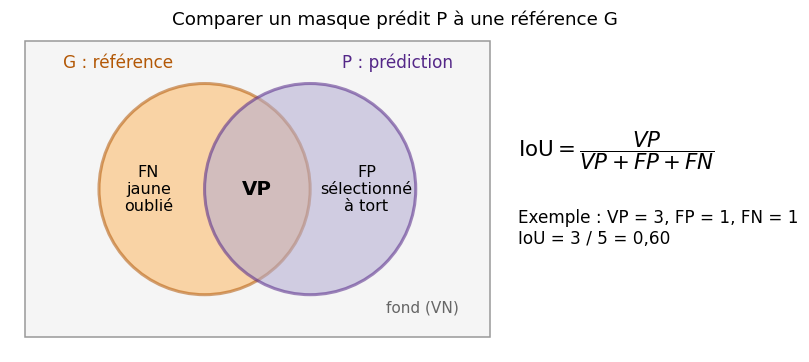

*Figure 4 : vrais positifs, faux positifs et faux négatifs pour un masque prédit P et une référence G.*

Avant de programmer, calculez à la main VP, FP, FN, précision, rappel et IoU
pour les deux petits masques suivants. Dans la fonction, les expressions
booléennes utiles sont `reference & prediction`, `~reference & prediction`
et `reference & ~prediction`. `np.sum` compte leurs pixels à "vrai".

La fonction retourne un dictionnaire dont les clés sont exactement `"VP"`,
`"FP"`, `"FN"`, `"précision"`, `"rappel"` et `"IoU"` : les sections suivantes
utilisent ces noms.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">&</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">~</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.sum</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.nan</code>.

</div></div>

In [ ]:
reference_mask = io.imread(RESOURCES / "05-balles-annotation-reference.png") > 0

small_reference = np.array([
    [1, 1, 0],
    [0, 1, 0],
    [0, 0, 1],
], dtype=bool)
small_prediction = np.array([
    [1, 0, 0],
    [0, 1, 1],
    [0, 0, 1],
], dtype=bool)


def binary_metrics(reference: np.ndarray, prediction: np.ndarray) -> dict:
    """Measure a binary prediction against a reference mask."""
    # TODO
    raise NotImplementedError


# Vérification attendue : VP=3, FP=1, FN=1, précision=0,75, rappel=0,75,
# IoU=0,60 (clés "VP", "FP", "FN", "précision", "rappel", "IoU")
# TODO : vérifier votre fonction sur small_reference et small_prediction

# TODO : calculer `hsv_scores = binary_metrics(reference_mask, hsv_mask)` et
# afficher les six entrées du dictionnaire

# TODO : calculer `my_hsv_scores` pour `my_hsv_parameters` et les comparer à
# `hsv_scores`

### Visualiser les erreurs

La superposition ne montre que les pixels sélectionnés : les faux négatifs y sont invisibles.
Complétez `error_map`, qui colore chaque pixel selon sa catégorie :

- fond : image assombrie (multipliée par 0,35) ;
- VP : gris clair (0,8 ; 0,8 ; 0,8) ;
- FP : orange (0,9 ; 0,6 ; 0) ;
- FN : bleu (0 ; 0,45 ; 0,7).

L'orange et le bleu restent distinguables pour la plupart des formes de daltonisme.

Procédez dans cet ordre :

1. Créez l'image de sortie assombrie : `output = 0.35 * image`. Elle a la même forme que `image`.
2. Calculez les trois masques booléens avec les expressions déjà utilisées dans `binary_metrics` :
   `vp = reference & prediction`, `fp = ~reference & prediction` et `fn = reference & ~prediction`.
3. Colorez chaque catégorie par indexation booléenne, par exemple
   `output[fp] = (0.9, 0.6, 0.0)` : tous les pixels où `fp` est vrai reçoivent ces trois valeurs RGB.
   Faites de même pour `vp` et `fn`.
4. Retournez `output`.

Affichez ensuite `error_map(balls, reference_mask, hsv_mask)` dans une grande figure,
`plt.subplots(figsize=(12, 8))`, avec le titre `"VP gris, FP orange, FN bleu"` et sans axes. Pour
examiner une zone précise, affichez une tranche de la carte, par exemple `carte[800:1200, 450:900]`.
Servez-vous de cette carte pour répondre à la question 7.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">reference & prediction</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">~reference & prediction</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">reference & ~prediction</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">output[fp] = (0.9, 0.6, 0.0)</code>.

</div></div>

In [ ]:
def error_map(
    image: np.ndarray, reference: np.ndarray, prediction: np.ndarray
) -> np.ndarray:
    """Color true positives, false positives and false negatives."""
    # TODO : étapes 1 à 4 de la consigne
    raise NotImplementedError


# TODO : calculer `carte = error_map(balls, reference_mask, hsv_mask)`, puis
# l'afficher avec le titre "VP gris, FP orange, FN bleu"

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 7**

Répondez séparément aux quatre points suivants :

1. Localisez la plus grande zone de faux positifs ; s'agit-il d'une erreur du détecteur ou d'un
   choix de la référence ?
2. Localisez les faux négatifs sur le bord inférieur gauche de la balle jaune du bas ; relevez H, S
   et V dans cette zone, observez les balles voisines, puis proposez une explication physique.
3. Repérez les fins liserés sélectionnés au contact d'une balle verte et d'une balle rouge ;
   expliquez pourquoi un pixel de bord peut avoir une teinte jaune.
4. Comparez la précision et le rappel, puis indiquez quel type d'erreur domine.

</div>

**Réponse à la question 7**

*Écrivez votre réponse ici.*

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 7 bis**

Donnez vos quatre seuils et, pour chacun, la mesure qui le justifie. Comparez l'IoU de votre réglage
à celui du réglage fourni, puis expliquez l'écart en indiquant quel type d'erreur, faux positifs ou
faux négatifs, change le plus.

</div>

**Réponse à la question 7 bis**

*Écrivez votre réponse ici.*

<div style="border:2px solid #6B7B7B;border-radius:6px;margin:0.8em 0;overflow:hidden;">
<div style="background:#414C4C;color:#fff;font-weight:bold;padding:4px 14px;">Point de contrôle n°2</div>
<div style="padding:4px 14px;">

Les sections 1 à 5 sont terminées lorsque votre masque, sa superposition et les six mesures sont
cohérents. Poursuivez avec les sections 6.1, 6.2 et 7.2, qui complètent la partie obligatoire.

</div></div>

# Validation et approfondissements

Les sections 6.1, 6.2 et 7.2 appartiennent à la partie obligatoire. Les sections
signalées "approfondissement" vont occuper ceux qui termineraient plus vite.
Elles comparent plusieurs stratégies et approfondissent la séparation entre
réglage, validation et mise à l'épreuve.

## 6. Un même objet avec des niveaux différents

Les images médicales, astronomiques ou industrielles sont souvent des images
scalaires plutôt que des photographies sRGB. Leurs valeurs peuvent changer
avec le gain, le temps d'acquisition, une transformation d'affichage ou un
prétraitement. Un seuil numérique fixé sur une image ne se transfère donc pas
nécessairement à une autre.

Les images de cette section contiennent le même carré. Sa géométrie est
connue exactement dans `11-carre-verite-terrain.png`. Les autres images ont
subi des transformations numériques contrôlées ; elles ne prétendent pas
reproduire un modèle physique complet de capteur.

### 6.1 Seuil absolu — partie obligatoire

Affichez les quatre images avec la même plage `vmin=0`, `vmax=1`. Choisissez
ensuite un seuil $T$ qui sépare le carré de son fond dans l'image de référence,
puis appliquez exactement ce même nombre aux trois variantes :

$$\boxed{\displaystyle M_T(x,y)=[I(x,y)>T]}$$

**Prédiction** 

Avant d'appliquer $T$ aux variantes, prédisez pour chacune si votre seuil fonctionnera, à partir des
niveaux du fond et du carré lus sur vos images affichées avec la même plage.

**Votre prédiction**

*Écrivez votre prédiction ici, avant d'exécuter la cellule de code suivante.*

Calculez ensuite l'IoU de chaque masque sans modifier $T$.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">image > T</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">binary_metrics</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">overlay_scalar</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.imshow(..., vmin=0, vmax=1)</code>.

</div></div>

In [ ]:
scalar_images = {
    "référence": util.img_as_float(io.imread(RESOURCES / "10-carre-reference.png")),
    "faible gain": util.img_as_float(io.imread(RESOURCES / "12-carre-faible-gain.png")),
    "décalée": util.img_as_float(io.imread(RESOURCES / "13-carre-decale.png")),
    "fond variable et bruit": util.img_as_float(
        io.imread(RESOURCES / "14-carre-fond-variable-bruit.png")
    ),
}
square_reference_mask = io.imread(RESOURCES / "11-carre-verite-terrain.png") > 0


def overlay_scalar(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Convert a scalar image to RGB, then overlay a binary mask."""
    image_rgb = np.repeat(util.img_as_float(image)[..., None], 3, axis=2)
    return overlay_mask(image_rgb, mask)

# Produisez les résultats suivants :
# - `scalar_absolute_masks` : un masque par image
# - `scalar_absolute_scores` : les métriques associées
# - une figure 2 x 4 montrant les images puis les superpositions
#
# Rangez votre seuil T dans `absolute_threshold`. Initialisez les deux
# dictionnaires vides. Dans une boucle sur
# `scalar_images.items()`, calculez `mask = image > absolute_threshold`, puis
# stockez le masque et le résultat de `binary_metrics`. Ne changez pas le seuil
# dans la boucle.

### 6.2 Normalisation robuste des niveaux — partie obligatoire

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : quantile**

Le quantile $P_q$ d'une image est la valeur sous laquelle se trouvent $q$ % de ses pixels. $P_{50}$ est la médiane. $P_2$ et $P_{98}$ écartent les 2 % de valeurs les plus basses et les 2 % les plus hautes, souvent du bruit ou des pixels aberrants.

**Exemple :** pour les dix valeurs 1, 2, ..., 10, la médiane vaut 5,5 et environ 20 % des valeurs sont inférieures ou égales à 2.

</div></div>

Une possibilité consiste à exprimer chaque image entre deux quantiles, $P_2(I)$ et $P_{98}(I)$ :

$$\boxed{\displaystyle N(I)=\operatorname{clip}\left(
\frac{I-P_2(I)}{P_{98}(I)-P_2(I)},0,1\right)}$$

Cette opération n'étalonne pas physiquement l'image et ne rend pas deux
acquisitions équivalentes. Elle ne réduit que l'effet d'un gain et d'un
décalage globaux lorsque les quantiles décrivent des populations comparables.
Elle peut échouer si la proportion d'objets change fortement, si des valeurs
aberrantes dominent les quantiles ou si la transformation est spatiale.

Complétez `robust_normalize` dans cet ordre : conversion en flottants, calcul
simultané des deux quantiles avec `np.percentile`, test du cas où ils sont
égaux avec `np.isclose`, application de la formule puis écrêtage. Dans le cas
dégénéré, retournez un tableau de zéros avec `np.zeros_like`.

Réglez ensuite un seuil sur l'image de référence normalisée, figez-le, puis
appliquez la même chaîne aux quatre images.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.percentile</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.isclose</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.zeros_like</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.clip</code>.

</div></div>

In [ ]:
def robust_normalize(
    image: np.ndarray, low_percentile: float = 2.0, high_percentile: float = 98.0
) -> np.ndarray:
    """Normalize a scalar image between two percentiles."""
    # TODO
    raise NotImplementedError


# Produisez les résultats suivants :
# - `scalar_normalized_images` : les quatre images normalisées
# - `scalar_normalized_masks` : les quatre masques obtenus avec le même seuil
# - `scalar_normalized_scores` : les métriques associées
# - un tableau de quatre lignes comparant les IoU avant et après normalisation
# - une figure 3 x 4 : image, superposition avant, superposition après
#
# TODO : normaliser, segmenter, afficher et mesurer les quatre images

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 8**

1. Vos prédictions de la section 6.1 étaient-elles justes ? Pour chaque variante, donnez l'IoU
   obtenue avec votre seuil $T$.
2. Citez les variantes dont l'IoU est améliorée par la normalisation.
3. Citez la variante pour laquelle la normalisation dégrade le résultat. Expliquez pourquoi un gain
   et un décalage globaux ne peuvent pas compenser un fond qui varie dans l'espace, puis nommez une
   méthode du cours adaptée à ce cas.
4. Expliquez pourquoi cette opération ne constitue pas un étalonnage physique.

</div>

**Réponse à la question 8**

*Écrivez votre réponse ici.*

### 6.3 Intervalle de seuils valides — partie approfondissement

Un seul seuil ne dit pas si le choix était robuste. Pour chacune des quatre images, brute puis
normalisée, tracez l'IoU en fonction de $T$ pour 101 valeurs entre 0 et 1 (`np.linspace(0, 1, 101)`).
Relevez ensuite, pour chaque courbe, l'intervalle des seuils testés qui donne une IoU supérieure à
0,99.
Les bornes obtenues ont donc une résolution de 0,01 et ne constituent pas des limites continues
exactes. Conservez les courbes dans `iou_curves_raw` et `iou_curves_normalized`, deux dictionnaires
indexés par le nom de l'image.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.linspace</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">robust_normalize</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">binary_metrics</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.plot</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.legend</code>.

</div></div>

In [ ]:
thresholds = np.linspace(0, 1, 101)
iou_curves_raw = {}
iou_curves_normalized = {}

# TODO : pour chaque image, calculer l'IoU de `image > T` et de
# `robust_normalize(image) > T` pour chaque seuil
# TODO : tracer les deux familles de courbes côte à côte, avec une légende
# TODO : afficher l'intervalle de seuils qui donne une IoU supérieure à 0,99

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 8 bis**

Pour chaque image, brute puis normalisée, donnez l'intervalle de seuils qui donne une IoU supérieure
à 0,99. Existe-t-il un seuil commun aux quatre images brutes ? Et après normalisation ? Que montrent
ces intervalles que votre seul seuil $T$ ne montrait pas ?

</div>

**Réponse à la question 8 bis**

*Écrivez votre réponse ici.*

## 7. Figer les paramètres HSV : perturbations contrôlées et nouvelle photographie

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : réglage, validation et test**

On règle les paramètres d'une méthode sur des images de réglage. On les fige, puis on vérifie la méthode sur des images de validation qui n'ont pas servi au réglage. Un test final, sur des données encore jamais vues, estime la performance réelle. Réussir sur les images de réglage ne prouve rien.

**Exemple :** dans ce TP, les seuils sont réglés sur l'image 04, validés sur la photographie 15 et testés en transfert sur la scène des fruits (09).

</div></div>

### 7.1 Perturbations contrôlées — partie approfondissement

Chargez les trois variantes colorées contrôlées. Ce sont des transformations numériques de la photo
de réglage : même scène, même géométrie et même éclairage réel. La même annotation de référence peut
donc être utilisée. Ces images testent la robustesse à des changements connus, pas la généralisation
à de nouvelles scènes.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Vos fonctions à réutiliser** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">segment_yellow_hsv</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">binary_metrics</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">overlay_mask</code>.

</div></div>

In [ ]:
perturbed_images = {
    "référence": balls,
    "assombrie": util.img_as_float(io.imread(RESOURCES / "06-balles-perturbation-assombrie.png")),
    "dominante chaude": util.img_as_float(
        io.imread(RESOURCES / "07-balles-perturbation-chaude.png")
    ),
    "gamma, froide et bruit": util.img_as_float(io.imread(RESOURCES / "08-balles-perturbation-gamma-froide-bruit.png")),
}

# Parcourez `perturbed_images.items()`. À chaque itération, appelez
# `segment_yellow_hsv(image, *hsv_parameters)`, puis `binary_metrics`. Sans
# modifier `hsv_parameters`, créez :
# - `perturbation_masks` : un masque par image
# - `perturbation_scores` : précision, rappel et IoU pour chaque image
# - une figure 1 x 4 des superpositions, avec l'IoU dans chaque titre
# - un tableau récapitulatif à quatre lignes

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 9**

Indiquez la meilleure et la moins bonne IoU du tableau. Pour la variante la moins bonne, précisez
quelle composante **H**, **S** ou **V** a changé et quel seuil du détecteur rejette alors des pixels
jaunes.

</div>

**Réponse à la question 9**

*Écrivez votre réponse ici.*

### 7.2 Valider sur une nouvelle photographie — partie obligatoire

Chargez `15-balles-validation.jpg` et son annotation `16-balles-validation-annotation.png`. 
Cette photographie montre d'autres balles, prises avec un autre appareil, au flash, dans un
plastique mat. Elle n'a servi à aucun réglage. 

Appliquez `segment_yellow_hsv` avec `hsv_parameters`, sans les modifier, puis `binary_metrics`. 
Produisez une figure 1 x 2 (image, superposition) avec l'IoU dans le titre. 
Conservez `new_photo_mask` et `new_photo_scores`. Évaluez aussi `my_hsv_parameters` sur la nouvelle
photographie.

Affichez aussi `error_map(new_photo, new_photo_reference, new_photo_mask)` de la même façon qu'à la
section 5 : cette carte vous servira pour la question 9 bis.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Vos fonctions à réutiliser** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">segment_yellow_hsv</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">binary_metrics</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">overlay_mask</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">error_map</code>.

</div></div>

In [ ]:
new_photo = util.img_as_float(io.imread(RESOURCES / "15-balles-validation.jpg"))
new_photo_reference = (
    io.imread(RESOURCES / "16-balles-validation-annotation.png") > 0
)

# TODO : calculer `new_photo_mask` avec `hsv_parameters`, sans modification
# TODO : calculer `new_photo_scores` avec `binary_metrics`, puis afficher une
# figure 1 x 2 (image, superposition) avec l'IoU dans le titre
# TODO : afficher la carte d'erreurs de la nouvelle photographie

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 9 bis**

Comparez l'IoU obtenue sur la nouvelle photographie à celle de l'image de réglage. Localisez la
principale zone de faux positifs, relevez R, G et B au centre de la balle concernée, puis expliquez
le lien avec l'écrêtage étudié à la section 2. Si votre propre réglage perd beaucoup plus que le
réglage fourni, comparez la teinte des balles jaunes des deux photographies. Terminez par trois
phrases indiquant ce qui a été réglé, ce qui a été mesuré sur une image indépendante et ce que vous
pouvez conclure sur la robustesse du détecteur.

</div>

**Réponse à la question 9 bis**

*Écrivez votre réponse ici.*

<div style="border:2px solid #6B7B7B;border-radius:6px;margin:0.8em 0;overflow:hidden;">
<div style="background:#414C4C;color:#fff;font-weight:bold;padding:4px 14px;">Fin de la partie obligatoire</div>
<div style="padding:4px 14px;">

Poursuivez avec l'approfondissement : sections 6.3 et 7.1,
puis 8 à 11.

</div></div>

## 8. Réglage automatique des seuils HSV — partie approfondissement

Automatisez le choix des paramètres HSV sur l'image de référence. Le but est
d'observer la différence entre une bonne performance de réglage et une bonne
performance sur de nouvelles images.

Suivez les étapes suivantes :

1. Estimez la teinte centrale à partir des échantillons jaunes.
2. Définissez des listes de tolérances de teinte, de seuils de saturation et
   de seuils de valeur.
3. Évaluez toutes les combinaisons sur l'image de référence.
4. Conservez celle qui maximise l'IoU.
5. Évaluez-la sans nouveau réglage sur les trois perturbations et sur la
   nouvelle photographie.

Pour chaque point de `yellow_points`, prélevez un carré de 25 x 25 pixels centré
sur ce point dans `hsv` et
transformez-le en une liste de pixels avec `.reshape(-1, 3)`. Rassemblez les
trois listes avec `np.concatenate`, puis prenez la médiane de H comme teinte
centrale.

Utilisez les grilles déjà définies dans la cellule. Trois boucles imbriquées
suffisent. La conversion HSV ne dépend pas des seuils : calculez une seule fois,
avant les boucles, la distance circulaire de teinte, la saturation et la
valeur. Pour chaque combinaison, construisez ensuite le masque directement à
partir de ces trois tableaux, calculez son IoU et remplacez le meilleur
résultat seulement si cette IoU est supérieure. Appeler
`segment_yellow_hsv` dans les boucles refait 125 fois la même conversion.
`time.perf_counter()` renvoie une horloge à haute résolution adaptée à une
mesure de durée. Mesurez la version précalculée. Pour éviter une attente
inutile, mesurez la version naïve sur 10 combinaisons, extrapolez sa durée à
125 combinaisons, puis donnez le rapport estimé entre les deux durées.

Une recherche sur grille est suffisante. Stockez les résultats dans
`best_hsv_parameters` et `best_iou`. Affichez ces valeurs et le nombre de
combinaisons évaluées, puis évaluez ces paramètres sur les quatre images de la
section 7.1 et sur la nouvelle photographie, sans les régler à nouveau.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.reshape(-1, 3)</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.concatenate</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.median</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">circular_hue_distance</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">time.perf_counter</code>.

</div></div>

In [ ]:
yellow_points = [(995, 500), (800, 875), (780, 110)]
hue_tolerances = np.linspace(0.03, 0.09, 5)
saturation_thresholds = np.linspace(0.25, 0.65, 5)
value_thresholds = np.linspace(0.15, 0.55, 5)

# TODO : prélever de petites régions autour des points jaunes et estimer la
# teinte centrale à partir de leurs pixels
# TODO : initialiser `best_iou`, `best_hsv_parameters` et un compteur, puis
# effectuer la recherche sur grille

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 10**

Comparez `hsv_parameters` et `best_hsv_parameters` sur l'image de réglage puis sur la nouvelle
photographie. Expliquez pourquoi le réglage qui gagne sur la première perd sur la seconde. Indiquez
enfin le rôle de chaque image : réglage (04), validation (15), transfert (09), et ce que les
perturbations 06 à 08 apportent en plus.

</div>

**Réponse à la question 10**

*Écrivez votre réponse ici.*

## 9. Mission de transfert : des balles aux fruits — partie approfondissement

Chargez `09-fruits-transfert.jpg`. Sans les modifier, appliquez
`segment_yellow_hsv` avec `hsv_parameters` à cette nouvelle scène.

Définissez ensuite deux petites régions rectangulaires entièrement situées :

- dans la banane ;
- dans l'orange.

Représentez chaque rectangle par `(x0, x1, y0, y1)`. Pour calculer la
proportion sélectionnée, extrayez `mask[y0:y1, x0:x1]` puis calculez sa
moyenne. Dessinez les rectangles sur l'image afin que le calcul soit
vérifiable.

Conservez les résultats sous les noms suivants :
- `fruits_hsv_mask` pour le masque complet ;
- `fruit_regions` pour les coordonnées des deux rectangles ;
- `fruit_selected_fractions` pour les deux proportions.

Produisez une figure 1 x 3 : image et rectangles, masque, superposition.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">segment_yellow_hsv</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">patches.Rectangle</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.add_patch</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.mean</code>.

</div></div>

In [ ]:
fruits = util.img_as_float(io.imread(RESOURCES / "09-fruits-transfert.jpg"))

def selected_fraction(mask: np.ndarray, rectangle: tuple[int, int, int, int]) -> float:
    """Return the fraction of selected pixels inside a rectangle."""
    # TODO : décomposer le rectangle, extraire le masque et calculer sa moyenne
    raise NotImplementedError


# TODO : calculer `fruits_hsv_mask` sans nouveau réglage
# TODO : définir `fruit_regions`, calculer `fruit_selected_fractions` et afficher

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 11**

Donnez les proportions mesurées dans la banane et l'orange. Citez ensuite au moins une zone
sélectionnée qui n'appartient pas à la banane, puis expliquez en une phrase pourquoi une couleur
ne définit pas un objet.

</div>

**Réponse à la question 11**

*Écrivez votre réponse ici.*

## 10. Mettre le détecteur en défaut — partie approfondissement

Une méthode robuste doit être évaluée au-delà des images qui ont servi à la
régler. Vous allez modifier l'image de référence de façon contrôlée, tout en
conservant exactement les paramètres `hsv_parameters` de votre détecteur.
Construisez la transformation numérique suivante :

$$\boxed{\displaystyle I' = \operatorname{clip}(g\,c\,I^{\gamma}, 0, 1)}$$

où $g$ est un gain global, $c=(c_R,c_G,c_B)$ contient un gain par canal et
$\gamma$ est un exposant. Cette transformation éprouve l'algorithme ; elle ne
constitue pas un modèle physique complet d'un capteur.

Dans la fonction, convertissez `channel_gains` en tableau NumPy de forme
`(1, 1, 3)` avec `.reshape`. Cette forme applique un gain différent à chaque
canal sur toute l'image par diffusion (*broadcasting*). Calculez ensuite la
formule en une seule expression et écrêtez entre 0 et 1.

**Prédiction chiffrée** 

Avant de tracer les courbes, calculez la valeur V médiane des pixels jaunes du masque de référence
avec `np.median(hsv[..., 2][reference_mask])`. Déduisez-en, à partir du seuil `value_min` de
`hsv_parameters`, le gain global à partir duquel le détecteur rejettera la majorité des pixels
jaunes. Notez ce gain avant de mesurer le point de rupture.

**Votre prédiction**

*Écrivez votre prédiction ici, avant d'exécuter la cellule de code suivante.*

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Définition : point de rupture**

Parmi les valeurs testées d'une perturbation, le point de rupture est celle qui est la plus proche de l'image intacte (gain 1) et qui fait tomber l'IoU strictement sous 0,60.

**Exemple :** si les gains 0,90, 0,80 et 0,70 donnent une IoU de 0,85, 0,62 et 0,41, le point de rupture vaut 0,70.

</div></div>

Suivez exactement ce protocole :

1. **Gain global** : utilisez `global_gains = np.linspace(0.20, 1.20, 31)`,
   fixez `channel_gains=(1, 1, 1)` et `gamma=1`, puis stockez les IoU dans
   `global_iou`.
2. **Gain vert** : utilisez `green_gains = np.linspace(0.50, 1.20, 36)`,
   fixez `global_gain=1`, `channel_gains=(1, green_gain, 1)` et `gamma=1`,
   puis stockez les IoU dans `green_iou`.
3. Tracez les deux courbes côte à côte, avec une ligne horizontale à
   $\mathrm{IoU}=0{,}60$.
4. Pour chaque courbe, relevez le **point de rupture** défini dans l'encadré
   ci-dessus. Si la courbe ne franchit pas 0,60, indiquez-le sans inventer de
   valeur.
5. Choisissez un des points de rupture observés et conservez l'image, le
   masque et les métriques dans `counterexample`, `counterexample_mask` et
   `counterexample_scores`. Stockez la valeur testée dans
   `counterexample_parameter`.
6. Affichez une figure 1 x 3 : image transformée, masque, superposition. Le
   paramètre modifié et l'IoU doivent apparaître dans les titres.

L'étude de $\gamma$ est facultative. Elle peut servir de prolongement si vous
terminez avant la fin du TP.

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.asarray</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">.reshape(1, 1, 3)</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">np.clip</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.plot</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axis.axhline</code>.

</div></div>

In [ ]:
def digital_perturbation(
    image: np.ndarray,
    global_gain: float = 1.0,
    channel_gains=(1.0, 1.0, 1.0),
    gamma: float = 1.0,
) -> np.ndarray:
    """Apply a controlled digital perturbation to an RGB image."""
    # TODO
    raise NotImplementedError


# Le squelette ci-dessous rappelle la construction des listes et des courbes.
# Complétez les expressions manquantes, puis ajoutez le calcul des deux points
# de rupture et la figure du contre-exemple.

global_gains = np.linspace(0.20, 1.20, 31)
green_gains = np.linspace(0.50, 1.20, 36)

global_iou = []
for gain in global_gains:
    changed = digital_perturbation(balls, global_gain=gain)
    mask = segment_yellow_hsv(changed, *hsv_parameters)
    # TODO : ajouter l'IoU à `global_iou`

green_iou = []
for green_gain in green_gains:
    changed = digital_perturbation(
        balls, channel_gains=(1.0, green_gain, 1.0)
    )
    mask = segment_yellow_hsv(changed, *hsv_parameters)
    # TODO : ajouter l'IoU à `green_iou`

# TODO : convertir les deux listes en tableaux NumPy

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# TODO : tracer une courbe sur chaque axe, nommer les axes et ajouter la ligne
# horizontale avec axis.axhline(0.60, color="red", linestyle="--")

# TODO : calculer les deux points de rupture
# TODO : créer `counterexample_parameter`, `counterexample`,
# `counterexample_mask` et `counterexample_scores`, puis afficher la figure 1 x 3

<div style="border-left:4px solid #6B7B7B;background:rgba(65,76,76,0.20);padding:2px 14px;margin:0.6em 0;">

**Question 12**

Répondez avec les valeurs mesurées :

1. donnez l'IoU sans perturbation et les deux points de rupture, s'ils existent
2. pour le contre-exemple retenu, indiquez quelles composantes H, S ou V ont changé et quel test
   logique du détecteur rejette les pixels
3. indiquez si les balles jaunes restent reconnaissables par un humain malgré une IoU inférieure à 0,60

</div>

**Réponse à la question 12**

*Écrivez votre réponse ici.*

## 11. Synthèse — partie approfondissement

Produisez une figure 2 x 3 dont les cases contiennent exactement :

1. `faible gain` avec le masque obtenu par seuil absolu et son IoU.
2. `faible gain` normalisée avec son masque et son IoU.
3. Balles de référence avec le masque HSV et son IoU.
4. Nouvelle photographie avec le masque HSV et son IoU.
5. Fruits avec le masque HSV et les proportions banane/orange dans le titre.
6. Contre-exemple avec son paramètre et son IoU.

Affichez toujours une superposition image-masque, masquez les axes et donnez un titre explicite à
chaque case. Réutilisez les variables demandées dans les sections précédentes : aucun nouveau
réglage n'est autorisé dans cette figure.

Pour éviter de répéter six fois le même code *Matplotlib*, construisez une liste `summary` de six
couples `(image_superposée, titre)`, puis utilisez :

```python
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, (image, title) in zip(axes.flat, summary):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
```

<div style="display:flex;gap:14px;align-items:flex-start;margin:0.6em 0 0.9em 0;">
<div style="flex:0 0 auto;width:1.8em;height:1.8em;border-radius:50%;background:#19407A;color:#fff;font-weight:bold;text-align:center;line-height:1.8em;font-family:Georgia,serif;">i</div>
<div style="flex:1;border-left:4px solid #3A6BB3;padding:0 14px;">

**Fonctions utiles** : <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">overlay_mask</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">overlay_scalar</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">plt.subplots</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">axes.flat</code>, <code style="background:#FFEFEE;color:#000;padding:1px 5px;border-radius:3px;">zip</code>.

</div></div>

In [ ]:
# TODO : construire les six couples de `summary`, puis exécuter le modèle donné

### Conclusion

Rédigez six réponses d'une ou deux phrases. Chaque réponse doit citer le
résultat numérique demandé lorsqu'il existe.

1. donnez le résultat observé du calcul en `uint8` qui déborde et expliquez-le
2. comparez les erreurs de reconstruction des méthodes de redimensionnement
   et indiquez l'information perdue lors de la réduction
3. donnez les IoU de `faible gain` avant et après normalisation, puis l'IoU de
   `fond variable et bruit` après normalisation
4. donnez l'IoU du réglage fourni sur l'image de réglage (04) et sur la
   nouvelle photographie (15), puis indiquez ce que cette comparaison permet de
   conclure
5. (si vous avez traité la section 9) donnez les proportions banane/orange et
   expliquez ce qu'elles démontrent
   sur la différence entre détecter une couleur et reconnaître un objet
6. proposez un jeu de test supplémentaire, en nommant précisément le facteur
   qui varierait et la mesure utilisée pour décider si la méthode est robuste

**Vos réponses**

*Écrivez vos six réponses ici.*

Avant de fermer le bloc-notes, redémarrez le noyau et exécutez toutes les
cellules dans l'ordre. Le bloc-notes doit conserver ses résultats et ne produire
aucune erreur.

---

#### Crédits des images

- `02` : (c) ENSICAEN, usage interne.
- `03` : "50 Euro Note", frankes, CC0, depuis Wikimedia Commons (Openclipart) ;
  rendu RGBA, coins et fenêtre transparents ajoutés.
- `04` à `08` : "Play balls", Petr Kratochvil, CC0, Public Domain Pictures ;
  `05` à `08` en sont dérivées.
- `09` : "Fruits!", Bhaskar Peddhapati, CC BY 2.0, depuis Wikimedia Commons
  (Flickr).
- `15` et `16` : "Toy balls with different Colors", Ramesh NG, CC BY-SA 2.0,
  depuis Wikimedia Commons ; `16` en est dérivée, sous la même licence.
- `01`, `10` à `14` : images synthétiques personnelles.
- Figures explicatives du sujet (indexation, espace HSV, distance circulaire,
  ensembles VP, FP, FN) : productions personnelles.

<div style="display:flex;justify-content:space-between;border-top:1px solid #8A8A8A;margin-top:2em;padding-top:3px;font-size:0.95em;">
<span>ENSICAEN</span><span>A.L</span>
</div>